<a href="https://colab.research.google.com/github/Roger-Quinelato/Shein_Eletronics/blob/main/Shein_Eletronics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/eletronics.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4394 entries, 0 to 4393
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   goods-title-link--jump       38 non-null     object 
 1   goods-title-link--jump href  38 non-null     object 
 2   rank-title                   747 non-null    object 
 3   rank-sub                     747 non-null    object 
 4   price                        4394 non-null   object 
 5   discount                     1525 non-null   object 
 6   selling_proposition          3167 non-null   object 
 7   color-count                  1138 non-null   float64
 8   goods-title-link             4356 non-null   object 
dtypes: float64(1), object(8)
memory usage: 309.1+ KB


In [2]:
df.head(3)

,goods-title-link--jump,goods-title-link--jump href,rank-title,rank-sub,price,discount,selling_proposition,color-count,goods-title-link
0,10pcs Random Color Data Cable Organizer,https://us.shein.com/10pcs-Random-Color-Data-C...,#10 Best Sellers,in Cable Storage,$1.36,-20%,NaN,NaN,NaN
1,3pcs Anti Glare Tempered Glass Front Film Phon...,https://us.shein.com/3pcs-Anti-Glare-Tempered-...,#1 Best Sellers,in Screen Protectors,$2.32,-20%,NaN,NaN,NaN
2,"Universal Waterproof Phone Pouch, Waterproof P...",https://us.shein.com/Universal-Waterproof-Phon...,NaN,NaN,$1.70,NaN,600+ sold recently,NaN,NaN




---

# **JUNÇÃO DAS CÉLULAS DE TRANSFORMAÇÃO**

---



In [3]:
colunas = {'goods-title-link--jump': 'nome', 'goods-title-link--jump href': 'link', 'rank-title':'rank vendas', 'rank-sub': 'sub-categoria','price': 'preço($)','discount': 'desconto(%)', 'selling_proposition':'qnt vendida', 'color-count':'cores disponiveis', 'goods-title-link'
:'nome_nome'}
df.rename(columns=colunas, inplace=True)

#---------------- DROPANDO COLUNA VAZIA -------------------------------------
df[['nome_nome']].isna().count()
df.drop(columns=['nome_nome'],inplace=True)

#---------------- FORMATANDO E TIPANDO CORRETAMENTE -------------------------
df['cores disponiveis'] = df['cores disponiveis'].fillna(1).astype(int)

df['desconto(%)'] = df['desconto(%)'].fillna(0)
df['desconto(%)'] = df['desconto(%)'].str.replace('-','').str.replace('%','').astype(float)

df['preço($)'] = df['preço($)'].str.replace('$','').str.replace(',','').astype(float)

df['sub-categoria'] = df['sub-categoria'].str.replace('in ', '')

df['rank vendas'] = df['rank vendas'].str.replace('Sellers', 'Seller').str.replace('#', '')

df['qnt vendida'] = df['qnt vendida'].str.replace('k', '000')\
.str.replace('.', '')\
.str.replace('+', '')\
.str.replace(' sold recently', '')

df.reset_index(drop=True)

#---------------- CRIANDO PREÇO TOTAL E REORGANIZANDO COLUNAS ===------------
df['preço original($)'] = df['preço($)'] / (1 - df['desconto(%)'] / 100)
renomear = ['nome','link',	'rank vendas',	'sub-categoria', 'preço original($)' ,'desconto(%)', 'preço($)','cores disponiveis','qnt vendida']
df = df.reindex(renomear, axis=1)

In [4]:
"""
CRIANDO A COLUNA COM O FOR E INTERROWS (COMO EU TENTEI FAZER ANTES - VAI FICAR COMO FONTE DE ESTUDOS)

"""
#-----------------------------------------
"""precos_originais = []

# Percorre linha por linha do DataFrame
for index, row in df.iterrows():
    preco = row['preço($)']
    desconto = row['desconto(%)']

    # Trata valores nulos e zero
    if pd.isna(desconto) or desconto == 0:
        precos_originais.append(preco)
    else:
        preco_original = round(preco / (1 - desconto / 100), 2)
        precos_originais.append(preco_original)

# Adiciona ao DataFrame
df['preço original($)'] = precos_originais

"""

"precos_originais = []\n\n# Percorre linha por linha do DataFrame\nfor index, row in df.iterrows():\n    preco = row['preço($)']\n    desconto = row['desconto(%)']\n\n    # Trata valores nulos e zero\n    if pd.isna(desconto) or desconto == 0:\n        precos_originais.append(preco)\n    else:\n        preco_original = round(preco / (1 - desconto / 100), 2)\n        precos_originais.append(preco_original)\n\n# Adiciona ao DataFrame\ndf['preço original($)'] = precos_originais\n\n"

In [5]:
df['qnt vendida'] = df['qnt vendida'].fillna('0').astype(int)
df['qnt vendida'].value_counts().sort_index(ascending=True)


,count
qnt vendida,
0,1227
10,90
20,76
30,55
40,70
...,...
89000,2
90000,2
94000,1


In [6]:
df['qnt vendida'] = pd.cut(df['qnt vendida'],
                           bins=[0, 10, 1000, 5000, 10000],
                           labels= ['0-10', '11-1000','1001-5000', '5000+'])
df['qnt vendida'].value_counts().sort_index(ascending=True)

,count
qnt vendida,
0-10,90
11-1000,2171
1001-5000,0
5000+,84


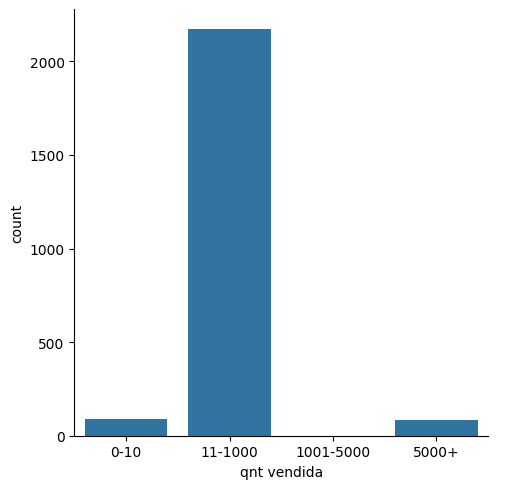

In [7]:
sns.catplot(data=df, x='qnt vendida', kind='count')
plt.show()

In [8]:
rank_rank = df['rank vendas'].value_counts().sort_index(ascending=True)
df['rank vendas'] = pd.Categorical(df['rank vendas'], categories=rank_rank.index, ordered=True)

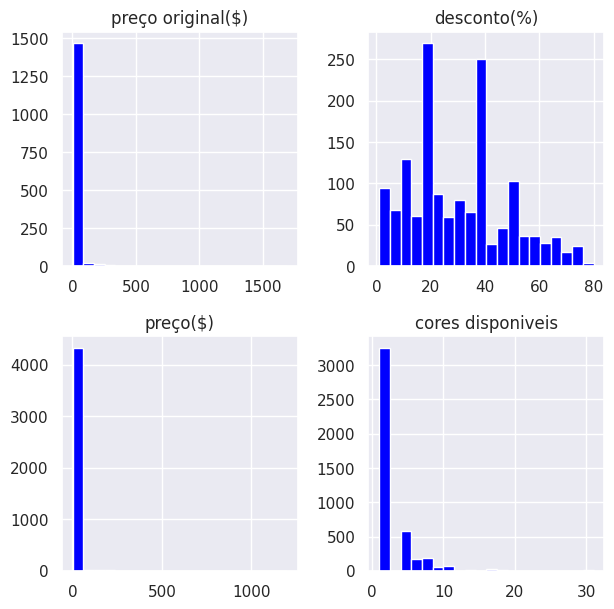

In [9]:
sns.set(font_scale=1, rc={'figure.figsize': (7,7)})
eixo = df[renomear].hist(bins=20, color='blue')

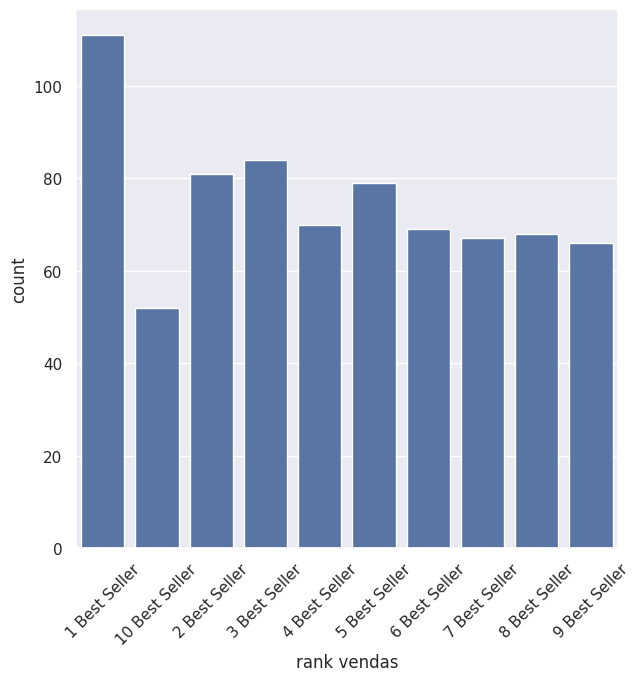

In [10]:
sns.countplot(data=df, x='rank vendas', order=rank_rank.index)
plt.xticks(rotation=45)
plt.show()

In [11]:
def duplicados(df):
    """Retorna a quantidade e a porcentagem de duplicados em cada coluna"""

    resultado = [] # DIFERENTE DO CASO DA PORCENTAGEM DOS Nº NULOS, AGORA PRECISA CRIAR UMA **LISTA DE DICIONÁRIO**

    for col in df.columns:
        total = len(df[col])
        duplicados = df[col].duplicated().sum()
        porcentagem = round((duplicados / total) * 100, 2)

        resultado.append({
            'Coluna': col,
            'Duplicados': duplicados,
            '% Duplicados': porcentagem
        })

    return pd.DataFrame(resultado)\
             .sort_values(by='Duplicados', ascending=False)\
             .reset_index(drop=True)

#------------------------------------------------------------------------



def detectar_categoricas(df, limite_absoluto=10, limite_percentual=0.1):
    """Detecta colunas que provavelmente são categóricas"""
    total_linhas = len(df)
    resultado = []

    for col in df.columns:
        unicos = df[col].nunique()
        perc = unicos / total_linhas

        if unicos <= limite_absoluto or perc <= limite_percentual:
            tipo = "Provavelmente Categórica"
        else:
            tipo = "Contínua ou Alta Cardinalidade"

        resultado.append({
            "Coluna": col,
            "Valores Únicos": unicos,
            "% Únicos": round(perc * 100, 2),
            "Tipo": tipo
        })

    return pd.DataFrame(resultado)\
    .sort_values(by="% Únicos")\
    .reset_index(drop=True)


In [12]:
duplicados(df)

,Coluna,Duplicados,% Duplicados
0,qnt vendida,4390,99.91
1,rank vendas,4383,99.75
2,cores disponiveis,4375,99.57
3,nome,4355,99.11
4,link,4355,99.11
5,desconto(%),4314,98.18
6,sub-categoria,4176,95.04
7,preço($),3728,84.84
8,preço original($),3525,80.22


In [13]:
detectar_categoricas(df)

,Coluna,Valores Únicos,% Únicos,Tipo
0,qnt vendida,3,0.07,Provavelmente Categórica
1,rank vendas,10,0.23,Provavelmente Categórica
2,cores disponiveis,19,0.43,Provavelmente Categórica
3,link,38,0.86,Provavelmente Categórica
4,nome,38,0.86,Provavelmente Categórica
5,desconto(%),79,1.80,Provavelmente Categórica
6,sub-categoria,217,4.94,Provavelmente Categórica
7,preço($),666,15.16,Contínua ou Alta Cardinalidade
8,preço original($),868,19.75,Contínua ou Alta Cardinalidade
